# 06 · 플러그인과 커넥터: 루프에 진짜 툴을 준다

**구성요소:** 플러그인과 커넥터(plugins & connectors) / MCP

**핵심 아이디어**

> "파일시스템만 읽을 수 있는 루프는 제한적이다. 커넥터(connector)는 루프가 진짜 툴에 손을 뻗게 해 준다… MCP 가 공통 기반이 되었다."

**문제 설정** — 구체적인 데이터에 대해 정밀한 계산을 요구하는 질문을 던진다. 가중치만 가진 모델은 그것을 **머릿속에서** 계산해야 하고, 데이터가 커질수록 더 많이 미끄러진다. 여기에 툴 하나 — 파이썬 실행기, 어떤 커넥터든 대신하는 대역 — 를 쥐여 주면 ReAct 에이전트는 추측하는 대신 정확한 답을 **계산해 낸다.**

**측정 대상** — 실제로 생성된 데이터에 대한 데이터 분석 질문의 정확도를, 툴이 없는 모델과 툴을 쓰는 ReAct 에이전트에 대해 각각 잰다. 데이터도 정답도 파이썬으로 계산되므로 정오 판정은 객관적이다. **그 격차가 곧 커넥터의 값어치다.**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

*ReAct 에이전트가 파이썬 툴을 호출하고, 실제 출력을 읽고, 그다음 답한다*

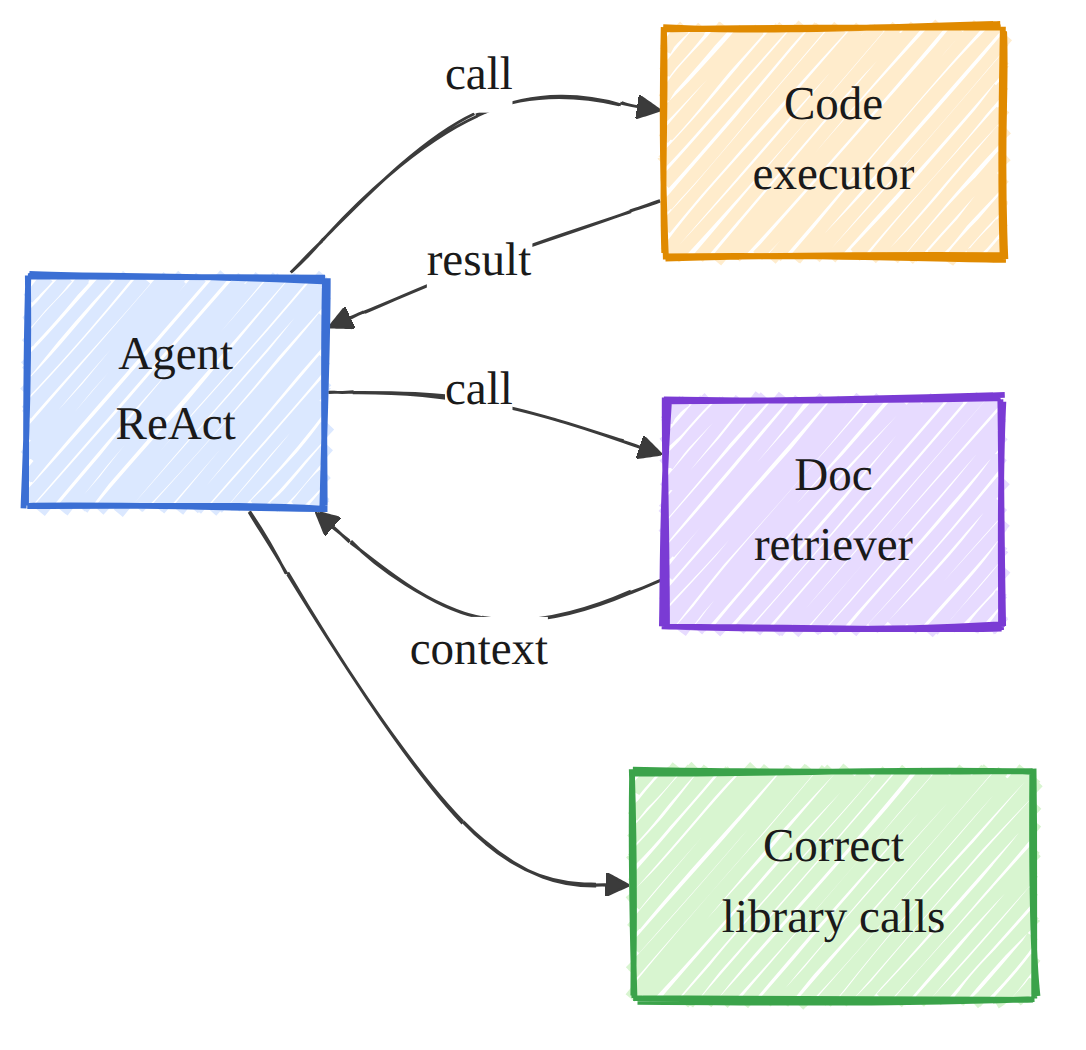

In [1]:
import os
import sys
import random

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, tools, plotting, runlog, runtime
from common.llm import LLM

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.show_dict(llm.health(), "엔진 health")
show.diagram("connectors_tools", "ReAct 에이전트가 파이썬 툴을 호출하고, 실제 출력을 읽고, 그다음 답한다")

# ── 정답이 객관적인 데이터 분석 과제를 만든다 ──────────────────────
# 질문도 정답도 파이썬으로 생성한다. 채점에 모델의 의견이 끼어들 자리가 없고,
# '툴이 있는가' 외의 변수가 결과에 섞이지 않는다.
rng = random.Random(11)      # seed 고정: 두 팔이 반드시 같은 문제를 본다


def make_task():
    # 리스트 길이를 25~40 으로 흩뜨린다. 산술 부담이 문항마다 달라야
    # '데이터가 커질수록 더 미끄러진다' 는 예측을 표에서 확인할 수 있다.
    nums = [rng.randint(1, 99) for _ in range(rng.randint(25, 40))]
    # 다섯 유형을 섞는 이유: 큰 합(산술 부담이 큼)과 작은 세기(부담이 없음)를
    # 함께 넣어야, 실패가 계산에서 오는지 명세에서 오는지 구분할 수 있다.
    kind = rng.choice(["sum_div", "count_prime", "max_minus_min", "count_increasing", "sum_even_idx"])
    if kind == "sum_div":
        d = rng.choice([3, 4, 7])
        q = f"Given the list {nums}, what is the sum of the elements divisible by {d}?"
        a = sum(x for x in nums if x % d == 0)
    elif kind == "count_prime":
        def isp(n):
            return n > 1 and all(n % i for i in range(2, int(n ** 0.5) + 1))
        q = f"Given the list {nums}, how many elements are prime?"
        a = sum(1 for x in nums if isp(x))
    elif kind == "max_minus_min":
        q = f"Given the list {nums}, what is the maximum minus the minimum?"
        a = max(nums) - min(nums)
    elif kind == "count_increasing":
        q = f"Given the list {nums}, how many adjacent pairs are strictly increasing?"
        a = sum(1 for i in range(len(nums) - 1) if nums[i + 1] > nums[i])
    else:
        q = f"Given the list {nums}, what is the sum of elements at even indices (0-based)?"
        a = sum(nums[i] for i in range(0, len(nums), 2))
    return {"q": q, "a": a}


# 30문제: 두 팔을 모두 돌려도 한 번의 실행으로 끝나면서, 몇 퍼센트 단위의
#         차이를 읽을 수 있는 크기다.
N = 30
tasks = [make_task() for _ in range(N)]
show.kv("과제 수", N)
show.text(tasks[0]["q"], "예시 과제", max_chars=300)
show.kv("예시의 참값", tasks[0]["a"])

from common import agents  # noqa: E402


def tool_answer(question):
    """에이전트가 코드 실행 커넥터에 위임한다: 코드를 쓰고, 실행하고, 출력을 읽는다."""
    # 프롬프트가 곧 툴 호출 계약이다. '숫자만', '파이썬 블록 하나' 라는 두 제약이
    # 아래 두 파서(extract_code, first_number)가 성립하기 위한 전제다.
    prompt = f"Write Python code that computes and prints ONLY the numeric answer. Return one python block.\n\n{question}"
    code = agents.extract_code(llm.complete(prompt, temperature=0.0, max_tokens=300, label="toolgen").text)
    # ⚠️ 함정: python_tool 은 모델이 쓴 코드를 그대로 실행한다. 즉 이 한 줄이
    #    임의 코드 실행(arbitrary code execution)이다. 시연에서는 손해가 없지만,
    #    실무 커넥터라면 샌드박스와 최소 권한이 붙기 전에는 배포할 수 없는 형태다.
    # ⚠️ 함정: first_number 는 stdout 의 '첫 숫자' 를 무조건 답으로 읽는다.
    #    코드가 진행 로그나 헤더를 먼저 찍으면 예외 없이 조용히 틀린 값이 답이 된다.
    #    파싱 계약의 실패는 오류가 아니라 오답의 형태로 나타난다.
    return tools.first_number(tools.python_tool(code))

## 추적: 툴 없는 추측 대 툴을 쓰는 에이전트


In [2]:
# ── 단일 과제 추적: 같은 질문, 실행 채널의 유무만 다르게 ───────────
t0 = tasks[0]
# max_tokens=32: '숫자만' 이라는 계약을 강제한다. 여기에는 부작용이 하나 있는데,
# 모델이 중간 계산을 적을 지면을 함께 빼앗는다는 것이다. 첫 이론 블록의 한계 참조.
nt = llm.complete(f"Answer with only the number.\n\n{t0['q']}", temperature=0.0, max_tokens=32, label="notool").text
show.kv("툴 없는 답", tools.first_number(nt))
show.kv("참값", t0["a"])
wt = tool_answer(t0["q"])
show.kv("툴을 쓴 답 (코드를 쓰고 실행한 결과)", wt)


  툴 없는 답:                    
  참값:                        17
  툴을 쓴 답 (코드를 쓰고 실행한 결과):    17


  tool answer (code written and executed): 17


## 대규모: 툴이 있을 때와 없을 때의 정확도


In [3]:
import time  # noqa: E402

# ── 대규모 실행: 30개 과제 × 2팔 ──────────────────────────────────
# 두 팔을 같은 반복 안에서 같은 문항에 대해 돌린다(짝지은 비교).
# 문항 난이도의 편차가 두 팔에 동일하게 걸려야 차이를 툴에 귀속시킬 수 있다.
nt_ok = wt_ok = 0
llm.reset_usage()      # 앞의 추적 셀이 쓴 토큰을 비용 집계에서 제외한다
start = time.time()
for t in tasks:
    nt = tools.first_number(llm.complete(f"Answer with only the number.\n\n{t['q']}", temperature=0.0, max_tokens=32, label="notool").text)
    wt = tool_answer(t["q"])
    # ⚠️ 함정: 문자열로 비교한다. 이 과제는 정답이 전부 정수라 안전하지만,
    #    실수형 답이 섞이면 '2.0' 과 '2' 가 불일치로 세어져 채점기부터 틀린다.
    #    채점기를 데이터에 맞추지 않고 결과를 해석하면 그때부터 측정이 아니다.
    nt_hit = str(nt) == str(t["a"])
    wt_hit = str(wt) == str(t["a"])
    nt_ok += nt_hit
    wt_ok += wt_hit
    # 맞으면 OK, 틀리면 실제로 낸 값을 찍는다. 오답의 '모양' 이 이 노트북의 증거다.
    print(f"  true={t['a']:<6} no-tool={'OK ' if nt_hit else nt:<6} tool={'OK' if wt_hit else wt}")
elapsed = time.time() - start

nt_acc, wt_acc = nt_ok / N, wt_ok / N
show.head("Results")
show.metric("툴 없는 정확도", nt_acc)
show.metric("툴 에이전트 정확도", wt_acc)
show.metric("토큰", llm.usage.total_tokens)

  true=17     no-tool=       tool=OK
  true=456    no-tool=       tool=OK
  true=9      no-tool=       tool=OK
  true=882    no-tool=       tool=OK
  true=576    no-tool=       tool=OK
  true=747    no-tool=       tool=OK
  true=284    no-tool=       tool=OK
  true=12     no-tool=       tool=OK
  true=95     no-tool=OK     tool=OK
  true=6      no-tool=       tool=OK
  true=87     no-tool=OK     tool=OK
  true=910    no-tool=       tool=OK
  true=696    no-tool=       tool=OK
  true=7      no-tool=       tool=
  true=1202   no-tool=       tool=OK
  true=14     no-tool=       tool=
  true=20     no-tool=       tool=OK
  true=14     no-tool=       tool=
  true=153    no-tool=       tool=
  true=9      no-tool=       tool=
  true=6      no-tool=       tool=
  true=861    no-tool=       tool=OK
  true=714    no-tool=       tool=OK
  true=76     no-tool=OK     tool=OK
  true=8      no-tool=       tool=OK
  true=623    no-tool=       tool=OK
  true=7      no-tool=       tool=OK
  true=6     

  true=456    no-tool=483    tool=OK


  true=9      no-tool=7      tool=OK


  true=882    no-tool=660    tool=OK


  true=576    no-tool=480    tool=OK


...

  true=623    no-tool=544    tool=OK


  true=7      no-tool=10     tool=OK


  true=6      no-tool=OK     tool=OK


  true=13     no-tool=4      tool=1


  true=18     no-tool=10     tool=OK

============================================= Results ==============================================
  no-tool accuracy                 0.1000
  tool-agent accuracy              0.8333
  tokens                           15490


## 그래프


  툴 에이전트 vs 툴 없음
    baseline : 0.1000
    treatment: 0.8000
    delta    : +0.7000  (+700.0 percent)  [up, improvement]


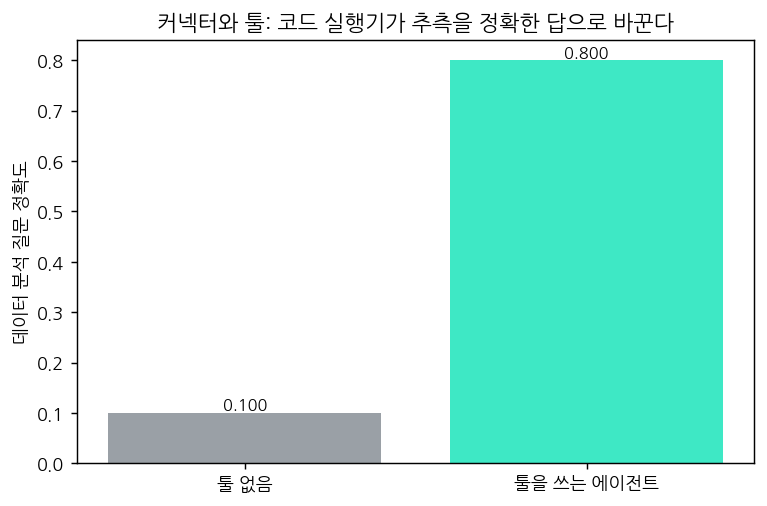

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/06_tools.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/06_connectors.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (connectors-tools: report-only, ~15375 tokens)


{'run_id': '2026-08-19T06:26:37Z',
 'pattern': 'connectors-tools',
 'duration_s': 102.2,
 'items_found': 30,
 'actions_taken': 24,
 'escalations': 0,
 'tokens_estimate': 15375,
 'outcome': 'report-only'}

In [4]:
# ── 비교, 그래프, 결과 저장 ───────────────────────────────────────
d = show.compare("툴 에이전트 vs 툴 없음", nt_acc, wt_acc)
plotting.ab_bar("06_tools", ["툴 없음", "툴을 쓰는 에이전트"], [nt_acc, wt_acc],
                "데이터 분석 질문 정확도", "커넥터와 툴: 코드 실행기가 추측을 정확한 답으로 바꾼다")

runlog.save_metrics("06_connectors", {"notebook": "06_connectors", "n": N, "no_tool": nt_acc,
                                       "provider": llm.provider,   # 한국어판 추가: 어느 백엔드의 수치인지 기록
                                       "model": llm.model,
                                       "tool_agent": wt_acc, "delta": d, "tokens": llm.usage.total_tokens})
# escalations=0: 이 노트북은 측정만 하고 아무것도 실행하지 않는다(outcome="report-only").
# 실제 커넥터를 붙인 루프라면 이 자리가 사람 게이트의 계측 지점이 된다.
runlog.log_run(pattern="connectors-tools", duration_s=elapsed, items_found=N, actions_taken=wt_ok,
               escalations=0, tokens_estimate=llm.usage.total_tokens, outcome="report-only")

## 이 실행이 실제로 보여 준 것


In [5]:
show.head("이 실행이 실제로 보여 준 것")
print(f"툴이 없을 때 모델은 데이터 분석 질문의 {nt_acc:.0%} 를 맞혔다.")
print("머릿속으로 계산했고, 리스트가 길어질수록 더 미끄러졌다.")
print(f"파이썬 툴(커넥터)이 있을 때 ReAct 에이전트는 {wt_acc:.0%} 에 도달했다 ({d['delta']:+.1%}).")
print("코드를 쓰고 실행하고, 진짜 출력을 읽고, 정확한 답을 보고했다.")
print()
# 여기서 툴 팔의 오답도 함께 보고한다. 상승폭만 찍고 끝내면 남은 실패의
# '종류' 가 바뀌었다는 이 노트북의 핵심이 출력에서 사라진다.
print("=> 커넥터는 루프가 추측을 그만두고 알기 시작하는 방법이다. 여기서 계산기를 돌리는")
print("   그 패턴이 실제 루프에서는 git, CI, 티켓, 데이터베이스를 돌린다.")
print(f"   다만 툴 팔도 {N - wt_ok}문제를 틀렸고, 그 오답은 계산이 아니라 명세에서 왔다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
툴이 없을 때 모델은 데이터 분석 질문의 10% 를 맞혔다.
머릿속으로 계산했고, 리스트가 길어질수록 더 미끄러졌다.
파이썬 툴(커넥터)이 있을 때 ReAct 에이전트는 80% 에 도달했다 (+70.0%).
코드를 쓰고 실행하고, 진짜 출력을 읽고, 정확한 답을 보고했다.

=> 커넥터는 루프가 추측을 그만두고 알기 시작하는 방법이다. 여기서 계산기를 돌리는
   그 패턴이 실제 루프에서는 git, CI, 티켓, 데이터베이스를 돌린다.
   다만 툴 팔도 6문제를 틀렸고, 그 오답은 계산이 아니라 명세에서 왔다.
